# Where Fulfillment Breaks
### Delivery Delay & Bottleneck Analysis | SQL, Python, Power BI | 96K Olist Orders

---

## Business Problem
Late orders hurt customer satisfaction and put revenue at risk, but it is unclear where in
the fulfillment process delays start and who is responsible. This analysis locates the
bottleneck, separates seller delay from carrier delay, and measures the impact on ratings
and revenue.

## Business Questions
1. What % of orders arrive late?
2. Do late deliveries hurt customer ratings compared to on-time deliveries?
3. How does the severity of the delay affect ratings?
4. Which fulfillment stage takes the most time?
5. Are delays caused by sellers or carriers?
6. How much revenue is tied to late orders?
7. Which states have the highest late rate?
8. Is lateness getting better or worse over time?
9. Which sellers have the highest late rate? (minimum 30 orders)
10. What should the company fix first?

In [1]:
# Necessary Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Preparing the Dataset
df = pd.read_csv("../data/order_fact.csv.zip")

df.head()

,order_id,customer_unique_id,customer_state,purchase_ts,approved_ts,carrier_ts,delivered_ts,estimated_ts,n_items,n_sellers,seller_id,shipping_limit_ts,item_revenue,freight_value,gmv,review_score,review_creation_date
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,SP,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,1,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71,4.0,2017-10-11 00:00:00
1,5ff96c15d0b717ac6ad1f3d77225a350,e2dfa3127fedbbca9707b36304996dab,SP,2018-07-25 17:44:10,2018-07-25 17:55:14,2018-07-26 13:16:00,2018-07-30 15:52:25,2018-08-08 00:00:00,1,1,1900267e848ceeba8fa32d80c1a5f5a8,2018-07-27 17:55:14,19.90,12.80,32.70,5.0,2018-07-31 00:00:00
2,dcb36b511fcac050b97cd5c05de84dc3,ccafc1c3f270410521c3c6f3b249870f,GO,2018-06-07 19:03:12,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32,2018-07-04 00:00:00,1,1,89a51f50b8095ea78d5768f34c13a76f,2018-06-18 18:59:02,132.40,14.05,146.45,5.0,2018-07-03 00:00:00
3,1790eea0b567cf50911c057cf20f90f9,a6fefcd9f434474cf6fcd8ed1102fd63,PE,2018-04-16 21:15:39,2018-04-16 22:10:26,2018-04-18 13:05:09,2018-05-05 12:28:34,2018-05-15 00:00:00,1,1,d91fb3b7d041e83b64a00a3edfb37e4f,2018-04-22 22:10:26,186.90,38.00,224.90,1.0,2018-05-06 00:00:00
4,68873cf91053cd11e6b49a766db5af1a,6da92ae920ab16fc4eceb8fcd7bd43ce,SP,2017-11-30 22:02:15,2017-12-02 02:51:18,2017-12-04 22:07:01,2017-12-05 20:28:40,2017-12-18 00:00:00,1,1,a673821011d0cec28146ea42f5ab767f,2017-12-07 02:51:18,79.90,11.76,91.66,4.0,2017-12-15 00:00:00


## Exploratory Data Analysis

In [3]:
# Information About Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96455 entries, 0 to 96454
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   order_id              96455 non-null  object 
 1   customer_unique_id    96455 non-null  object 
 2   customer_state        96455 non-null  object 
 3   purchase_ts           96455 non-null  object 
 4   approved_ts           96455 non-null  object 
 5   carrier_ts            96455 non-null  object 
 6   delivered_ts          96455 non-null  object 
 7   estimated_ts          96455 non-null  object 
 8   n_items               96455 non-null  int64  
 9   n_sellers             96455 non-null  int64  
 10  seller_id             95180 non-null  object 
 11  shipping_limit_ts     96455 non-null  object 
 12  item_revenue          96455 non-null  float64
 13  freight_value         96455 non-null  float64
 14  gmv                   96455 non-null  float64
 15  review_score       

In [4]:
# Checking Total Null Values
print(df.isnull().sum())

order_id                   0
customer_unique_id         0
customer_state             0
purchase_ts                0
approved_ts                0
carrier_ts                 0
delivered_ts               0
estimated_ts               0
n_items                    0
n_sellers                  0
seller_id               1275
shipping_limit_ts          0
item_revenue               0
freight_value              0
gmv                        0
review_score             646
review_creation_date     646
dtype: int64


In [5]:
# Dataset Description
df.describe()

,n_items,n_sellers,item_revenue,freight_value,gmv,review_score
count,96455.000000,96455.000000,96455.000000,96455.000000,96455.000000,95809.000000
mean,1.142222,1.013903,137.042139,22.786240,159.828379,4.155758
std,0.538857,0.123551,209.065278,21.561412,218.815346,1.284887
min,1.000000,1.000000,0.850000,0.000000,9.590000,1.000000
25%,1.000000,1.000000,45.900000,13.850000,61.850000,4.000000
50%,1.000000,1.000000,86.500000,17.170000,105.280000,5.000000
75%,1.000000,1.000000,149.900000,24.020000,176.260000,5.000000
max,21.000000,5.000000,13440.000000,1794.960000,13664.080000,5.000000


In [6]:
df.columns

Index(['order_id', 'customer_unique_id', 'customer_state', 'purchase_ts',
       'approved_ts', 'carrier_ts', 'delivered_ts', 'estimated_ts', 'n_items',
       'n_sellers', 'seller_id', 'shipping_limit_ts', 'item_revenue',
       'freight_value', 'gmv', 'review_score', 'review_creation_date'],
      dtype='object')

## Feature Engineering

In [7]:
# Converting into date/time values
time_cols = [
    "purchase_ts",
    "approved_ts",
    "carrier_ts",
    "delivered_ts",
    "estimated_ts",
    "shipping_limit_ts"
]

for c in time_cols:
    df[c] = pd.to_datetime(df[c])

In [8]:
# Calculate delay in days
df["days_late"] = (df.delivered_ts.dt.normalize() - df.estimated_ts.dt.normalize()).dt.days
df["is_late"] = df["days_late"] > 0
# Create delay buckets
df["late_bucket"] = pd.cut(
    df["days_late"],
    [-np.inf, 0, 3, 7, np.inf],
    labels=["On-time", "1-3d late", "4-7d late", "8+d late"]
)
print(df["late_bucket"].value_counts())

late_bucket
On-time      89922
8+d late      2862
1-3d late     1870
4-7d late     1801
Name: count, dtype: int64


In [9]:
df["seller_late"] = df.carrier_ts.dt.normalize() > df.shipping_limit_ts.dt.normalize()

df["approval_days"] = (df.approved_ts  - df.purchase_ts).dt.total_seconds() / 86400
df["handoff_days"]  = (df.carrier_ts   - df.approved_ts).dt.total_seconds() / 86400
df["carrier_days"]  = (df.delivered_ts - df.carrier_ts).dt.total_seconds() / 86400

## Analysis

### Q1: What % of orders arrive late?

In [10]:
print("Late rate %:", round(df.is_late.mean() * 100, 1))

Late rate %: 6.8


6.8% of orders arrive late.

### Q2: Do late deliveries negatively impact customer satisfaction compared to on-time deliveries?

In [11]:
print(df.groupby("is_late").review_score.mean())

is_late
False    4.290264
True     2.270376
Name: review_score, dtype: float64


Late orders average 2.27 stars vs 4.29 for on-time orders.

### Q3: How does the severity of delivery delay affect customer satisfaction?

late_bucket
On-time      4.290264
1-3d late    3.291037
4-7d late    2.103034
8+d late     1.695793
Name: review_score, dtype: float64


C:\Users\rajde\AppData\Local\Temp\ipykernel_4108\1417451529.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("late_bucket")["review_score"].mean().plot(


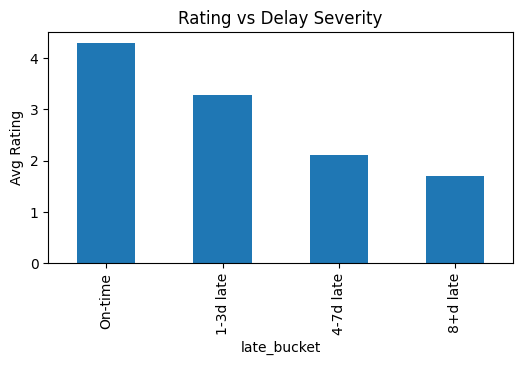

In [12]:
print(df.groupby("late_bucket", observed=True).review_score.mean())

# Visual Understanding
df.groupby("late_bucket")["review_score"].mean().plot(
    kind="bar",
    figsize=(6,3),
    title="Rating vs Delay Severity"
)
plt.ylabel("Avg Rating")
plt.show()

Ratings fall at every step: 4.29, then 3.29, 2.10, and 1.70 for orders 8+ days late.

### Q4: Which delivery stage takes the most time?

         approval_days  handoff_days  carrier_days
is_late                                           
False              0.0           1.8           7.0
True               0.0           3.1          26.2


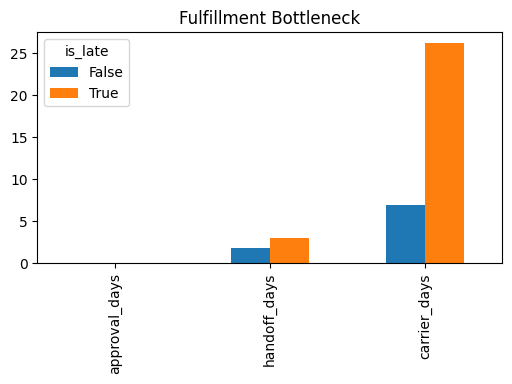

In [13]:
valid = df[(df.approval_days >= 0) & (df.handoff_days >= 0) & (df.carrier_days >= 0)]
print(valid.groupby("is_late")[["approval_days", "handoff_days", "carrier_days"]].median().round(1))

# Visual Understanding
valid.groupby("is_late")[["approval_days","handoff_days","carrier_days"]].median().T.plot(
    kind="bar",
    figsize=(6,3),
    title="Fulfillment Bottleneck"
)
plt.show()

The carrier stage takes 26 days for late orders vs 7 for on-time orders, so it is the bottleneck.

### Q5: Are delays caused by sellers or carriers?

In [14]:
late = df[df.is_late]
print("Seller handed over late: %.1f%% of late orders" % (late.seller_late.mean() * 100))
print("Seller on time, carrier late: %.1f%%" % ((1 - late.seller_late.mean()) * 100))

Seller handed over late: 22.3% of late orders
Seller on time, carrier late: 77.7%


78% of late orders are carrier-only, and 22% involve a late seller handoff.

### Q6: How much revenue is tied to late orders?

In [15]:
total = df.gmv.sum()
late_rev = df[df.is_late].gmv.sum()
late_bad = df[df.is_late & (df.review_score <= 2)].gmv.sum()

print("Revenue on late orders: %.0f (%.1f%% of total)" % (late_rev, late_rev / total * 100))
print("Of which got 1-2 star reviews: %.0f" % late_bad)

Revenue on late orders: 1150698 (7.5% of total)
Of which got 1-2 star reviews: 720783


Late orders carry 1.15M in revenue (7.5% of total), and 721K of it (63%) got a 1-2 star review. This is revenue exposed, not revenue lost.

### Q7: Which states have the highest late rate?

In [16]:
# Top 10 states by late %
print(
    (df.groupby("customer_state")
       .agg(orders=("order_id","size"), late_pct=("is_late","mean"))
       .query("orders >= 500")
       .sort_values("late_pct", ascending=False)
       .head(10)["late_pct"] * 100
    ).round(1)
)

customer_state
MA    17.5
CE    13.8
BA    12.2
RJ    12.1
PA    11.2
ES    10.7
PB    10.4
MS     9.7
PE     9.6
SC     8.2
Name: late_pct, dtype: float64


### Q8: Is lateness getting better or worse over time?

purchase_ts
2017-01     2.9
2017-02     3.0
2017-03     4.6
2017-04     6.6
2017-05     3.0
2017-06     3.0
2017-07     2.8
2017-08     2.9
2017-09     4.4
2017-10     4.2
2017-11    12.4
2017-12     7.5
2018-01     5.7
2018-02    14.1
2018-03    19.0
2018-04     4.5
2018-05     6.6
2018-06     1.2
2018-07     3.4
2018-08     6.2
Freq: M, Name: is_late, dtype: float64


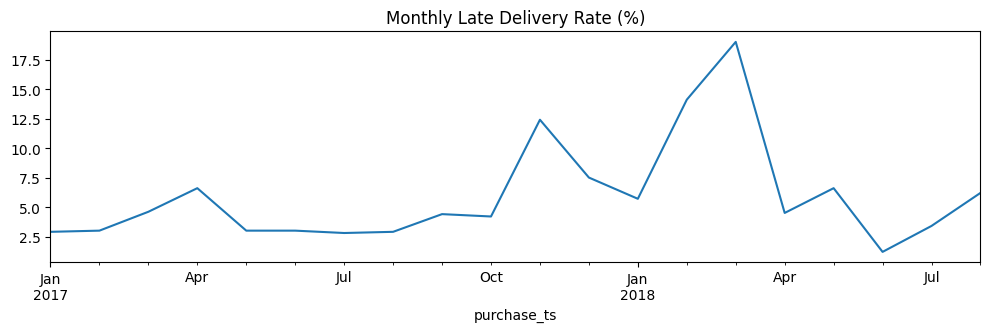

In [17]:
# Monthly late delivery %
m = df.groupby(df.purchase_ts.dt.to_period("M"))["is_late"].mean() * 100
m = m[m.index.map(df.groupby(df.purchase_ts.dt.to_period("M")).size() >= 500)].round(1)
print(m)

# Visual understanding
m.plot(figsize=(12, 3), title="Monthly Late Delivery Rate (%)")
plt.show()

Late rates spiked in Nov 2017 (12.4%) and Feb to Mar 2018 (14.1% and 19.0%), against a normal level of about 3 to 6%.

### Q9: Which sellers have the highest late rate?

In [18]:
s = df.groupby("seller_id").agg(
    orders=("order_id", "size"),
    seller_late_pct=("seller_late", "mean")
)

s["seller_late_pct"] = (s["seller_late_pct"] * 100).round(1)

result = s.query("orders >= 30").sort_values("seller_late_pct", ascending=False)

print(len(result))
print(result.head(10))

615
                                  orders  seller_late_pct
seller_id                                                
48efc9d94a9834137efd9ea76b065a38      33             84.8
835f0f7810c76831d6c7d24c7a646d4d      40             75.0
a7f13822ceb966b076af67121f87b063      73             53.4
1da366cade6d8276e7d8beea7af5d4bf      41             51.2
ad781527c93d00d89a11eecd9dcad7c1      33             48.5
88460e8ebdecbfecb5f9601833981930     227             47.1
54965bbe3e4f07ae045b90b0b8541f52      72             45.8
a49928bcdf77c55c6d6e05e09a9b4ca5      93             44.1
23613d49c3ac2bd302259e55c06c050c      62             35.5
8e6d7754bc7e0f22c96d255ebda59eba      77             35.1


Of 615 sellers with 30+ orders, three hand over late in over 53% of their orders.

### Q10: What should the company fix first?

1. **Carrier transit** :-  About 78% of late orders are carrier-only, and the late carrier
   stage takes about 4x longer than on-time (26 vs 7 days).
2. **The northeast routes** :- MA, CE and BA have the highest late rates (12-18%),
   against 6.8% overall.
3. **A small group of sellers** :-  Seller handoff is late in 22% of late orders, and a
   few high-volume sellers are late in more than 40% of their orders.
4. **Peak periods** :-  Nov 2017 and Feb-Mar 2018 had late rates 2-3x normal, so
   capacity planning for peaks matters.

**Why it matters:** late orders drop from 4.29 to as low as 1.70 stars ratings, and about
1.15M (7.5%) of revenue sits on late orders.